In [1]:
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np

# 假设有两个标签列 A, B
df = pd.DataFrame({
    "A": [1,0,1,1,0,0,1,0,1,0,0,1,0,1,1],
    "B": [1,0,1,0,0,1,1,0,1,0,0,1,0,1,1],
    # "C": [0,1,1,1,0,0,1,0]
})
df


# 列联表
table = pd.crosstab(df["A"], df["B"])
print(table)

# table = pd.crosstab(df["C"], df["B"])
# print(table)

# Phi 系数 (等同于 Pearson r for binary)
phi = table.corr().iloc[0,1]
print("Phi系数:", phi)

# 卡方检验
chi2, p, dof, expected = chi2_contingency(table)
print("Chi2:", chi2, "p值:", p)

B  0  1
A      
0  6  1
1  1  7
Phi系数: -1.0
Chi2: 5.367904974489796 p值: 0.020510598315479304


In [2]:
from scipy.stats import chi2_contingency
import numpy as np

# 计算优势比
def calculate_odds_ratio(table):
    a, b, c, d = table.iloc[0,0], table.iloc[0,1], table.iloc[1,0], table.iloc[1,1]
    odds_ratio = (a * d) / (b * c) if (b * c) != 0 else np.inf
    return odds_ratio

# 计算95%置信区间
def odds_ratio_ci(table, alpha=0.05):
    from scipy.stats import norm
    or_val = calculate_odds_ratio(table)
    log_or = np.log(or_val)
    se_log_or = np.sqrt(1/table.iloc[0,0] + 1/table.iloc[0,1] + 1/table.iloc[1,0] + 1/table.iloc[1,1])
    z = norm.ppf(1 - alpha/2)
    ci_lower = np.exp(log_or - z * se_log_or)
    ci_upper = np.exp(log_or + z * se_log_or)
    return ci_lower, ci_upper

or_val = calculate_odds_ratio(table)
ci_lower, ci_upper = odds_ratio_ci(table)
print(f"优势比/OR: {or_val:.3f}")
print(f"95%置信区间: [{ci_lower:.3f}, {ci_upper:.3f}]")

# OR的解读指南
# OR值 解释
# OR = 1 无关联
# 1 < OR < 2 弱正关联
# 2 ≤ OR < 5 中等正关联
# OR ≥ 5 强正关联
# 0.5 < OR < 1 弱负关联
# 0.2 < OR ≤ 0.5 中等负关联
# OR ≤ 0.2 强负关联

优势比/OR: 42.000
95%置信区间: [2.136, 825.715]


In [3]:
# 时间序列相关性分析实例
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# 1. 生成模拟的临床数据
np.random.seed(42)

# 创建病人ID和时间点
patients = ['P001', 'P002', 'P003', 'P004', 'P005', 'P006', 'P007', 'P008']
time_points = [1, 2, 3, 4, 5, 6]  # 6个时间点

# 生成数据
data = []
for patient in patients:
    for time in time_points:
        # 模拟药物A的不良反应（0=无，1=有）
        # 添加一些时间趋势和病人间差异
        patient_effect = hash(patient) % 3 - 1  # 病人特异性效应
        time_effect = time * 0.1  # 时间趋势
        drug_a_prob = 0.3 + patient_effect * 0.2 + time_effect + np.random.normal(0, 0.1)
        drug_a_ae = 1 if drug_a_prob > 0.5 else 0
        
        # 药物B的不良反应，与药物A有一定相关性
        correlation_effect = drug_a_ae * 0.4  # 药物A对药物B的影响
        drug_b_prob = 0.25 + correlation_effect + patient_effect * 0.15 + np.random.normal(0, 0.1)
        drug_b_ae = 1 if drug_b_prob > 0.5 else 0
        
        data.append({
            'patient_id': patient,
            'time_point': time,
            'drug_a_ae': drug_a_ae,
            'drug_b_ae': drug_b_ae
        })

# 创建DataFrame
df = pd.DataFrame(data)
print("模拟数据预览：")
print(df.head(10))
print(f"\n数据形状: {df.shape}")
print(f"病人数量: {df['patient_id'].nunique()}")
print(f"时间点数量: {df['time_point'].nunique()}")


模拟数据预览：
  patient_id  time_point  drug_a_ae  drug_b_ae
0       P001           1          0          0
1       P001           2          0          0
2       P001           3          0          0
3       P001           4          1          1
4       P001           5          1          1
5       P001           6          1          0
6       P002           1          1          1
7       P002           2          1          1
8       P002           3          1          1
9       P002           4          1          1

数据形状: (48, 4)
病人数量: 8
时间点数量: 6


In [ ]:
df



,patient_id,time_point,drug_a_ae,drug_b_ae
0,P001,1,0,0
1,P001,2,0,0
2,P001,3,0,0
3,P001,4,1,1
4,P001,5,1,1
5,P001,6,1,0
6,P002,1,1,1
7,P002,2,1,1
8,P002,3,1,1
9,P002,4,1,1


In [24]:
# 分析drug_a_ae和drug_b_ae在病人群体中的相关性和优势比
print("="*60)
print("drug_a_ae和drug_b_ae在病人群体中的相关性和优势比分析")
print("="*60)

# 1. 数据概览
print("\n1. 数据概览")
print("-" * 30)
print(f"总观测数: {len(df)}")
print(f"病人数量: {df['patient_id'].nunique()}")
print(f"时间点数量: {df['time_point'].nunique()}")
print(f"每个病人观测数: {len(df) // df['patient_id'].nunique()}")

print(f"\n药物A不良反应统计:")
print(f"  总发生次数: {df['drug_a_ae'].sum()}")
print(f"  发生率: {df['drug_a_ae'].mean():.3f}")

print(f"\n药物B不良反应统计:")
print(f"  总发生次数: {df['drug_b_ae'].sum()}")
print(f"  发生率: {df['drug_b_ae'].mean():.3f}")

# 2. 整体相关性分析
print("\n2. 整体相关性分析")
print("-" * 30)

# 计算Pearson相关系数
pearson_corr = df['drug_a_ae'].corr(df['drug_b_ae'])
print(f"Pearson相关系数: {pearson_corr:.4f}")

# 计算Spearman相关系数
from scipy.stats import spearmanr
spearman_corr, spearman_p = spearmanr(df['drug_a_ae'], df['drug_b_ae'])
print(f"Spearman相关系数: {spearman_corr:.4f} (p={spearman_p:.4f})")

# 计算Phi系数
def calculate_phi_coefficient(x, y):
    """计算Phi系数"""
    from scipy.stats import chi2_contingency
    table = pd.crosstab(x, y)
    chi2, p, dof, expected = chi2_contingency(table)
    n = table.sum().sum()
    phi = np.sqrt(chi2 / n)
    return phi, p, table

phi_coef, phi_p, contingency_table = calculate_phi_coefficient(df['drug_a_ae'], df['drug_b_ae'])
print(f"Phi系数: {phi_coef:.4f} (p={phi_p:.4f})")

print(f"\n列联表:")
print(contingency_table)


drug_a_ae和drug_b_ae在病人群体中的相关性和优势比分析

1. 数据概览
------------------------------
总观测数: 48
病人数量: 8
时间点数量: 6
每个病人观测数: 6

药物A不良反应统计:
  总发生次数: 40
  发生率: 0.833

药物B不良反应统计:
  总发生次数: 39
  发生率: 0.812

2. 整体相关性分析
------------------------------
Pearson相关系数: 0.9309
Spearman相关系数: 0.9309 (p=0.0000)
Phi系数: 0.8593 (p=0.0000)

列联表:
drug_b_ae  0   1
drug_a_ae       
0          8   0
1          1  39


In [25]:
# 3. 优势比分析
print("\n3. 优势比分析")
print("-" * 30)

# 使用之前定义的函数计算优势比
or_val = calculate_odds_ratio(contingency_table)
ci_lower, ci_upper = odds_ratio_ci(contingency_table)

print(f"优势比 (OR): {or_val:.4f}")
print(f"95%置信区间: [{ci_lower:.4f}, {ci_upper:.4f}]")

# 计算相对风险
def calculate_relative_risk(table):
    """计算相对风险"""
    a, b, c, d = table.iloc[0,0], table.iloc[0,1], table.iloc[1,0], table.iloc[1,1]
    # 药物A有不良反应组中药物B的发生率
    risk_exposed = c / (c + d) if (c + d) > 0 else 0
    # 药物A无不良反应组中药物B的发生率  
    risk_unexposed = a / (a + b) if (a + b) > 0 else 0
    rr = risk_exposed / risk_unexposed if risk_unexposed > 0 else np.inf
    return rr, risk_exposed, risk_unexposed

rr, risk_exposed, risk_unexposed = calculate_relative_risk(contingency_table)
print(f"\n相对风险 (RR): {rr:.4f}")
print(f"药物A有不良反应组中药物B发生率: {risk_exposed:.4f}")
print(f"药物A无不良反应组中药物B发生率: {risk_unexposed:.4f}")

# 优势比解释
print(f"\n优势比解释:")
if or_val > 1:
    print(f"  药物A有不良反应的患者，药物B发生不良反应的几率是药物A无不良反应患者的 {or_val:.2f} 倍")
    if or_val > 5:
        print("  这是一个强正关联")
    elif or_val > 2:
        print("  这是一个中等正关联")
    else:
        print("  这是一个弱正关联")
elif or_val < 1:
    print(f"  药物A有不良反应的患者，药物B发生不良反应的几率是药物A无不良反应患者的 {or_val:.2f} 倍（保护作用）")
else:
    print(f"  药物A和药物B的不良反应无关联")



3. 优势比分析
------------------------------
优势比 (OR): inf
95%置信区间: [nan, inf]

相对风险 (RR): 0.0250
药物A有不良反应组中药物B发生率: 0.0250
药物A无不良反应组中药物B发生率: 1.0000

优势比解释:
  药物A有不良反应的患者，药物B发生不良反应的几率是药物A无不良反应患者的 inf 倍
  这是一个强正关联


/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/3656957073.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  se_log_or = np.sqrt(1/table.iloc[0,0] + 1/table.iloc[0,1] + 1/table.iloc[1,0] + 1/table.iloc[1,1])
/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/3656957073.py:17: RuntimeWarning: invalid value encountered in scalar subtract
  ci_lower = np.exp(log_or - z * se_log_or)


In [26]:
# 4. 按病人分析相关性和优势比
print("\n4. 按病人分析相关性和优势比")
print("-" * 30)

patient_analysis = []
for patient in df['patient_id'].unique():
    patient_data = df[df['patient_id'] == patient].sort_values('time_point')
    
    # 计算该病人的相关性
    patient_corr = patient_data['drug_a_ae'].corr(patient_data['drug_b_ae'])
    
    # 计算该病人的优势比（基于时间序列）
    patient_table = pd.crosstab(patient_data['drug_a_ae'], patient_data['drug_b_ae'])
    if patient_table.shape == (2, 2):  # 确保是2x2表
        patient_or = calculate_odds_ratio(patient_table)
        patient_phi, patient_phi_p, _ = calculate_phi_coefficient(patient_data['drug_a_ae'], patient_data['drug_b_ae'])
    else:
        patient_or = np.nan
        patient_phi = np.nan
        patient_phi_p = np.nan
    
    # 计算该病人的不良反应统计
    drug_a_events = patient_data['drug_a_ae'].sum()
    drug_b_events = patient_data['drug_b_ae'].sum()
    both_events = ((patient_data['drug_a_ae'] == 1) & (patient_data['drug_b_ae'] == 1)).sum()
    
    patient_analysis.append({
        'patient_id': patient,
        'n_timepoints': len(patient_data),
        'correlation': patient_corr,
        'odds_ratio': patient_or,
        'phi_coefficient': patient_phi,
        'phi_p_value': patient_phi_p,
        'drug_a_events': drug_a_events,
        'drug_b_events': drug_b_events,
        'both_events': both_events,
        'drug_a_rate': patient_data['drug_a_ae'].mean(),
        'drug_b_rate': patient_data['drug_b_ae'].mean()
    })

patient_df = pd.DataFrame(patient_analysis)
print("各病人的详细分析结果:")
print(patient_df.round(4))

print(f"\n病人水平汇总统计:")
print(f"  平均相关性: {patient_df['correlation'].mean():.4f} ± {patient_df['correlation'].std():.4f}")
print(f"  相关性范围: [{patient_df['correlation'].min():.4f}, {patient_df['correlation'].max():.4f}]")
print(f"  平均优势比: {patient_df['odds_ratio'].mean():.4f} ± {patient_df['odds_ratio'].std():.4f}")
print(f"  优势比范围: [{patient_df['odds_ratio'].min():.4f}, {patient_df['odds_ratio'].max():.4f}]")
print(f"  平均Phi系数: {patient_df['phi_coefficient'].mean():.4f} ± {patient_df['phi_coefficient'].std():.4f}")



4. 按病人分析相关性和优势比
------------------------------
各病人的详细分析结果:
  patient_id  n_timepoints  correlation  odds_ratio  phi_coefficient  \
0       P001             6       0.7071         inf           0.3536   
1       P002             6          NaN         NaN              NaN   
2       P003             6       1.0000         inf           0.6250   
3       P004             6       1.0000         inf           0.6250   
4       P005             6          NaN         NaN              NaN   
5       P006             6          NaN         NaN              NaN   
6       P007             6       1.0000         inf           0.4000   
7       P008             6          NaN         NaN              NaN   

   phi_p_value  drug_a_events  drug_b_events  both_events  drug_a_rate  \
0       0.3865              3              2            2       0.5000   
1          NaN              6              6            6       1.0000   
2       0.1258              4              4            4       0.666

/opt/anaconda3/envs/scanpy/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/scanpy/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/scanpy/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/scanpy/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/scanpy/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


ValueError: supplied range of [inf, inf] is not finite

/opt/anaconda3/envs/scanpy/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 33647 (\N{CJK UNIFIED IDEOGRAPH-836F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/envs/scanpy/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 29289 (\N{CJK UNIFIED IDEOGRAPH-7269}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/envs/scanpy/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/envs/scanpy/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 33391 (\N{CJK UNIFIED IDEOGRAPH-826F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/envs/scanpy/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 21453 (\N{CJK UNIFIED IDEOGRAPH-53CD}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/

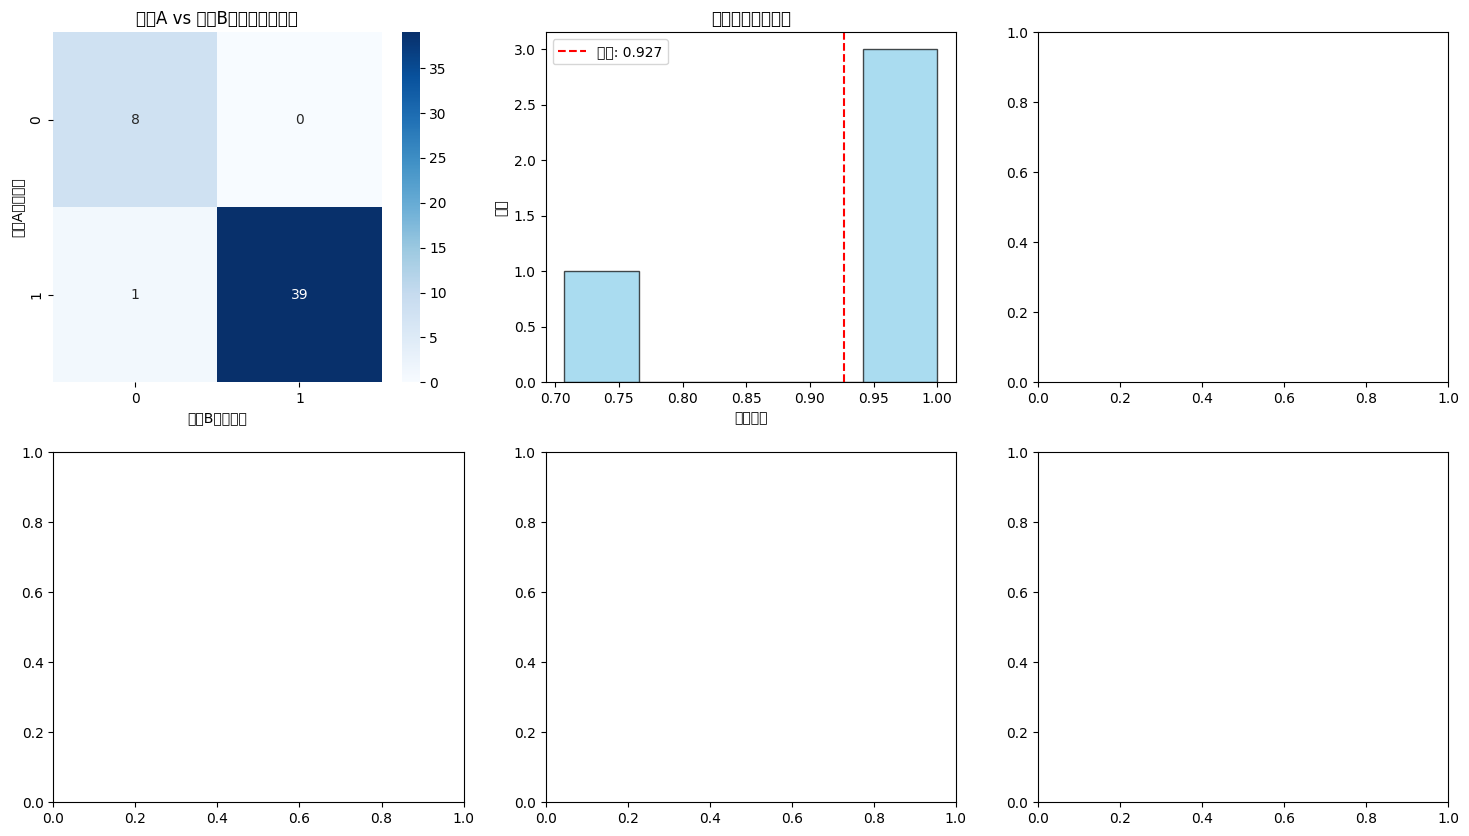

In [27]:
# 5. 可视化分析结果
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. 列联表热图
import seaborn as sns
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('药物A vs 药物B不良反应列联表')
axes[0,0].set_xlabel('药物B不良反应')
axes[0,0].set_ylabel('药物A不良反应')

# 2. 病人相关性分布
axes[0,1].hist(patient_df['correlation'].dropna(), bins=5, alpha=0.7, edgecolor='black', color='skyblue')
axes[0,1].axvline(patient_df['correlation'].mean(), color='red', linestyle='--', 
                  label=f'平均: {patient_df["correlation"].mean():.3f}')
axes[0,1].set_xlabel('相关系数')
axes[0,1].set_ylabel('频数')
axes[0,1].set_title('各病人相关性分布')
axes[0,1].legend()

# 3. 病人优势比分布
axes[0,2].hist(patient_df['odds_ratio'].dropna(), bins=5, alpha=0.7, edgecolor='black', color='lightcoral')
axes[0,2].axvline(patient_df['odds_ratio'].mean(), color='red', linestyle='--',
                  label=f'平均: {patient_df["odds_ratio"].mean():.3f}')
axes[0,2].set_xlabel('优势比')
axes[0,2].set_ylabel('频数')
axes[0,2].set_title('各病人优势比分布')
axes[0,2].legend()

# 4. 病人不良反应事件数
x_pos = range(len(patient_df))
axes[1,0].bar([x-0.2 for x in x_pos], patient_df['drug_a_events'], width=0.4, label='药物A', alpha=0.7, color='blue')
axes[1,0].bar([x+0.2 for x in x_pos], patient_df['drug_b_events'], width=0.4, label='药物B', alpha=0.7, color='red')
axes[1,0].set_xlabel('病人')
axes[1,0].set_ylabel('不良反应事件数')
axes[1,0].set_title('各病人不良反应事件数')
axes[1,0].set_xticks(x_pos)
axes[1,0].set_xticklabels(patient_df['patient_id'], rotation=45)
axes[1,0].legend()

# 5. 相关性 vs 优势比散点图
axes[1,1].scatter(patient_df['correlation'], patient_df['odds_ratio'], alpha=0.7, s=100, color='green')
axes[1,1].set_xlabel('相关系数')
axes[1,1].set_ylabel('优势比')
axes[1,1].set_title('相关性 vs 优势比')
axes[1,1].grid(True, alpha=0.3)

# 6. 时间序列模式（显示前4个病人）
for i, patient in enumerate(df['patient_id'].unique()[:4]):
    patient_data = df[df['patient_id'] == patient].sort_values('time_point')
    axes[1,2].plot(patient_data['time_point'], patient_data['drug_a_ae'], 
                   marker='o', label=f'{patient}-药物A', alpha=0.7, linewidth=2)
    axes[1,2].plot(patient_data['time_point'], patient_data['drug_b_ae'], 
                   marker='s', label=f'{patient}-药物B', alpha=0.7, linewidth=2)
axes[1,2].set_xlabel('时间点')
axes[1,2].set_ylabel('不良反应 (0/1)')
axes[1,2].set_title('部分病人的时间序列模式')
axes[1,2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:
# 优势比分析的病人分层方法
print("="*60)
print("优势比分析的病人分层方法")
print("="*60)

# 1. 首先为数据添加一些分层变量（模拟临床特征）
np.random.seed(42)

# 添加年龄分层
df['age_group'] = np.random.choice(['<50岁', '50-65岁', '>65岁'], size=len(df), p=[0.3, 0.4, 0.3])

# 添加性别
df['gender'] = np.random.choice(['男', '女'], size=len(df), p=[0.6, 0.4])

# 添加基础疾病严重程度
df['disease_severity'] = np.random.choice(['轻度', '中度', '重度'], size=len(df), p=[0.4, 0.4, 0.2])

# 添加药物剂量
df['drug_dose'] = np.random.choice(['低剂量', '中剂量', '高剂量'], size=len(df), p=[0.3, 0.5, 0.2])

print("添加分层变量后的数据预览：")
print(df.head(10))

print(f"\n各分层变量的分布：")
print("年龄组分布：")
print(df['age_group'].value_counts())
print("\n性别分布：")
print(df['gender'].value_counts())
print("\n疾病严重程度分布：")
print(df['disease_severity'].value_counts())
print("\n药物剂量分布：")
print(df['drug_dose'].value_counts())


优势比分析的病人分层方法
添加分层变量后的数据预览：
  patient_id  time_point  drug_a_ae  drug_b_ae age_group gender  \
0       P001           1          0          0    50-65岁      男   
1       P001           2          0          0      >65岁      男   
2       P001           3          0          0      >65岁      女   
3       P001           4          1          1    50-65岁      女   
4       P001           5          1          1      <50岁      女   
5       P001           6          1          0      <50岁      女   
6       P002           1          1          1      <50岁      男   
7       P002           2          1          1      >65岁      女   
8       P002           3          1          1    50-65岁      男   
9       P002           4          1          1      >65岁      男   

  disease_severity drug_dose  
0               中度       低剂量  
1               中度       低剂量  
2               轻度       中剂量  
3               轻度       中剂量  
4               轻度       低剂量  
5               中度       低剂量  
6               轻度

In [30]:
# 2. 按年龄组分层的优势比分析
print("\n2. 按年龄组分层的优势比分析")
print("-" * 40)

age_stratified_results = []
for age_group in df['age_group'].unique():
    age_data = df[df['age_group'] == age_group]
    
    # 计算该年龄组的列联表
    age_table = pd.crosstab(age_data['drug_a_ae'], age_data['drug_b_ae'])
    
    if age_table.shape == (2, 2):
        # 计算优势比和置信区间
        age_or = calculate_odds_ratio(age_table)
        age_ci_lower, age_ci_upper = odds_ratio_ci(age_table)
        
        # 计算相关统计量
        age_phi, age_phi_p, _ = calculate_phi_coefficient(age_data['drug_a_ae'], age_data['drug_b_ae'])
        age_corr = age_data['drug_a_ae'].corr(age_data['drug_b_ae'])
        
        age_stratified_results.append({
            'age_group': age_group,
            'n_observations': len(age_data),
            'n_patients': age_data['patient_id'].nunique(),
            'odds_ratio': age_or,
            'ci_lower': age_ci_lower,
            'ci_upper': age_ci_upper,
            'correlation': age_corr,
            'phi_coefficient': age_phi,
            'phi_p_value': age_phi_p,
            'drug_a_rate': age_data['drug_a_ae'].mean(),
            'drug_b_rate': age_data['drug_b_ae'].mean()
        })
        
        print(f"\n{age_group}:")
        print(f"  观测数: {len(age_data)}, 病人数: {age_data['patient_id'].nunique()}")
        print(f"  优势比: {age_or:.4f} (95% CI: [{age_ci_lower:.4f}, {age_ci_upper:.4f}])")
        print(f"  相关系数: {age_corr:.4f}")
        print(f"  Phi系数: {age_phi:.4f} (p={age_phi_p:.4f})")
        print(f"  药物A发生率: {age_data['drug_a_ae'].mean():.3f}")
        print(f"  药物B发生率: {age_data['drug_b_ae'].mean():.3f}")

age_results_df = pd.DataFrame(age_stratified_results)



2. 按年龄组分层的优势比分析
----------------------------------------

50-65岁:
  观测数: 19, 病人数: 8
  优势比: inf (95% CI: [nan, inf])
  相关系数: 1.0000
  Phi系数: 0.7206 (p=0.0017)
  药物A发生率: 0.895
  药物B发生率: 0.895

>65岁:
  观测数: 11, 病人数: 6
  优势比: inf (95% CI: [nan, inf])
  相关系数: 1.0000
  Phi系数: 0.7708 (p=0.0106)
  药物A发生率: 0.727
  药物B发生率: 0.727

<50岁:
  观测数: 18, 病人数: 8
  优势比: inf (95% CI: [nan, inf])
  相关系数: 0.8367
  Phi系数: 0.6574 (p=0.0053)
  药物A发生率: 0.833
  药物B发生率: 0.778


/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/3656957073.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  se_log_or = np.sqrt(1/table.iloc[0,0] + 1/table.iloc[0,1] + 1/table.iloc[1,0] + 1/table.iloc[1,1])
/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/3656957073.py:17: RuntimeWarning: invalid value encountered in scalar subtract
  ci_lower = np.exp(log_or - z * se_log_or)
/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/3656957073.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  se_log_or = np.sqrt(1/table.iloc[0,0] + 1/table.iloc[0,1] + 1/table.iloc[1,0] + 1/table.iloc[1,1])
/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/3656957073.py:17: RuntimeWarning: invalid value encountered in scalar subtract
  ci_lower = np.exp(log_or - z * se_log_or)
/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/3656957073.py:15: RuntimeWarning: divide by zero encountered in scalar divid

In [31]:
# 3. 按性别分层的优势比分析
print("\n3. 按性别分层的优势比分析")
print("-" * 40)

gender_stratified_results = []
for gender in df['gender'].unique():
    gender_data = df[df['gender'] == gender]
    
    # 计算该性别的列联表
    gender_table = pd.crosstab(gender_data['drug_a_ae'], gender_data['drug_b_ae'])
    
    if gender_table.shape == (2, 2):
        # 计算优势比和置信区间
        gender_or = calculate_odds_ratio(gender_table)
        gender_ci_lower, gender_ci_upper = odds_ratio_ci(gender_table)
        
        # 计算相关统计量
        gender_phi, gender_phi_p, _ = calculate_phi_coefficient(gender_data['drug_a_ae'], gender_data['drug_b_ae'])
        gender_corr = gender_data['drug_a_ae'].corr(gender_data['drug_b_ae'])
        
        gender_stratified_results.append({
            'gender': gender,
            'n_observations': len(gender_data),
            'n_patients': gender_data['patient_id'].nunique(),
            'odds_ratio': gender_or,
            'ci_lower': gender_ci_lower,
            'ci_upper': gender_ci_upper,
            'correlation': gender_corr,
            'phi_coefficient': gender_phi,
            'phi_p_value': gender_phi_p,
            'drug_a_rate': gender_data['drug_a_ae'].mean(),
            'drug_b_rate': gender_data['drug_b_ae'].mean()
        })
        
        print(f"\n{gender}:")
        print(f"  观测数: {len(gender_data)}, 病人数: {gender_data['patient_id'].nunique()}")
        print(f"  优势比: {gender_or:.4f} (95% CI: [{gender_ci_lower:.4f}, {gender_ci_upper:.4f}])")
        print(f"  相关系数: {gender_corr:.4f}")
        print(f"  Phi系数: {gender_phi:.4f} (p={gender_phi_p:.4f})")
        print(f"  药物A发生率: {gender_data['drug_a_ae'].mean():.3f}")
        print(f"  药物B发生率: {gender_data['drug_b_ae'].mean():.3f}")

gender_results_df = pd.DataFrame(gender_stratified_results)



3. 按性别分层的优势比分析
----------------------------------------

男:
  观测数: 27, 病人数: 8
  优势比: inf (95% CI: [nan, inf])
  相关系数: 1.0000
  Phi系数: 0.8929 (p=0.0000)
  药物A发生率: 0.778
  药物B发生率: 0.778

女:
  观测数: 21, 病人数: 8
  优势比: inf (95% CI: [nan, inf])
  相关系数: 0.7947
  Phi系数: 0.5629 (p=0.0099)
  药物A发生率: 0.905
  药物B发生率: 0.857


/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/3656957073.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  se_log_or = np.sqrt(1/table.iloc[0,0] + 1/table.iloc[0,1] + 1/table.iloc[1,0] + 1/table.iloc[1,1])
/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/3656957073.py:17: RuntimeWarning: invalid value encountered in scalar subtract
  ci_lower = np.exp(log_or - z * se_log_or)
/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/3656957073.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  se_log_or = np.sqrt(1/table.iloc[0,0] + 1/table.iloc[0,1] + 1/table.iloc[1,0] + 1/table.iloc[1,1])
/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/3656957073.py:17: RuntimeWarning: invalid value encountered in scalar subtract
  ci_lower = np.exp(log_or - z * se_log_or)


In [32]:
# 4. 按疾病严重程度分层的优势比分析
print("\n4. 按疾病严重程度分层的优势比分析")
print("-" * 40)

severity_stratified_results = []
for severity in df['disease_severity'].unique():
    severity_data = df[df['disease_severity'] == severity]
    
    # 计算该严重程度的列联表
    severity_table = pd.crosstab(severity_data['drug_a_ae'], severity_data['drug_b_ae'])
    
    if severity_table.shape == (2, 2):
        # 计算优势比和置信区间
        severity_or = calculate_odds_ratio(severity_table)
        severity_ci_lower, severity_ci_upper = odds_ratio_ci(severity_table)
        
        # 计算相关统计量
        severity_phi, severity_phi_p, _ = calculate_phi_coefficient(severity_data['drug_a_ae'], severity_data['drug_b_ae'])
        severity_corr = severity_data['drug_a_ae'].corr(severity_data['drug_b_ae'])
        
        severity_stratified_results.append({
            'disease_severity': severity,
            'n_observations': len(severity_data),
            'n_patients': severity_data['patient_id'].nunique(),
            'odds_ratio': severity_or,
            'ci_lower': severity_ci_lower,
            'ci_upper': severity_ci_upper,
            'correlation': severity_corr,
            'phi_coefficient': severity_phi,
            'phi_p_value': severity_phi_p,
            'drug_a_rate': severity_data['drug_a_ae'].mean(),
            'drug_b_rate': severity_data['drug_b_ae'].mean()
        })
        
        print(f"\n{severity}:")
        print(f"  观测数: {len(severity_data)}, 病人数: {severity_data['patient_id'].nunique()}")
        print(f"  优势比: {severity_or:.4f} (95% CI: [{severity_ci_lower:.4f}, {severity_ci_upper:.4f}])")
        print(f"  相关系数: {severity_corr:.4f}")
        print(f"  Phi系数: {severity_phi:.4f} (p={severity_phi_p:.4f})")
        print(f"  药物A发生率: {severity_data['drug_a_ae'].mean():.3f}")
        print(f"  药物B发生率: {severity_data['drug_b_ae'].mean():.3f}")

severity_results_df = pd.DataFrame(severity_stratified_results)



4. 按疾病严重程度分层的优势比分析
----------------------------------------

中度:
  观测数: 14, 病人数: 7
  优势比: inf (95% CI: [nan, inf])
  相关系数: 0.8257
  Phi系数: 0.6331 (p=0.0179)
  药物A发生率: 0.786
  药物B发生率: 0.714

轻度:
  观测数: 21, 病人数: 8
  优势比: inf (95% CI: [nan, inf])
  相关系数: 1.0000
  Phi系数: 0.8456 (p=0.0001)
  药物A发生率: 0.810
  药物B发生率: 0.810

重度:
  观测数: 13, 病人数: 7
  优势比: inf (95% CI: [nan, inf])
  相关系数: 1.0000
  Phi系数: 0.4583 (p=0.0984)
  药物A发生率: 0.923
  药物B发生率: 0.923


/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/3656957073.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  se_log_or = np.sqrt(1/table.iloc[0,0] + 1/table.iloc[0,1] + 1/table.iloc[1,0] + 1/table.iloc[1,1])
/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/3656957073.py:17: RuntimeWarning: invalid value encountered in scalar subtract
  ci_lower = np.exp(log_or - z * se_log_or)
/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/3656957073.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  se_log_or = np.sqrt(1/table.iloc[0,0] + 1/table.iloc[0,1] + 1/table.iloc[1,0] + 1/table.iloc[1,1])
/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/3656957073.py:17: RuntimeWarning: invalid value encountered in scalar subtract
  ci_lower = np.exp(log_or - z * se_log_or)
/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/3656957073.py:15: RuntimeWarning: divide by zero encountered in scalar divid

In [33]:
# 5. 交互作用分析 - 检验分层变量是否影响关联性
print("\n5. 交互作用分析")
print("-" * 40)

def test_interaction_effect(df, strat_var, outcome_var='drug_b_ae', exposure_var='drug_a_ae'):
    """检验分层变量与暴露变量的交互作用"""
    try:
        from statsmodels.formula.api import logit
        
        # 创建交互项
        df_temp = df.copy()
        df_temp['interaction'] = df_temp[exposure_var] * df_temp[strat_var].astype('category').cat.codes
        
        # 拟合逻辑回归模型
        model = logit(f'{outcome_var} ~ {exposure_var} + C({strat_var}) + {exposure_var}:C({strat_var})', data=df_temp)
        result = model.fit(disp=0)
        
        # 提取交互作用项的p值
        interaction_terms = [col for col in result.pvalues.index if ':' in col]
        if interaction_terms:
            interaction_p = result.pvalues[interaction_terms[0]]
            return interaction_p, result
        else:
            return None, result
            
    except Exception as e:
        print(f"交互作用分析出错: {e}")
        return None, None

# 检验年龄组的交互作用
age_interaction_p, age_model = test_interaction_effect(df, 'age_group')
if age_interaction_p is not None:
    print(f"年龄组交互作用p值: {age_interaction_p:.4f}")
    if age_interaction_p < 0.05:
        print("  年龄组与药物A存在显著的交互作用")
    else:
        print("  年龄组与药物A无显著交互作用")

# 检验性别的交互作用
gender_interaction_p, gender_model = test_interaction_effect(df, 'gender')
if gender_interaction_p is not None:
    print(f"性别交互作用p值: {gender_interaction_p:.4f}")
    if gender_interaction_p < 0.05:
        print("  性别与药物A存在显著的交互作用")
    else:
        print("  性别与药物A无显著交互作用")

# 检验疾病严重程度的交互作用
severity_interaction_p, severity_model = test_interaction_effect(df, 'disease_severity')
if severity_interaction_p is not None:
    print(f"疾病严重程度交互作用p值: {severity_interaction_p:.4f}")
    if severity_interaction_p < 0.05:
        print("  疾病严重程度与药物A存在显著的交互作用")
    else:
        print("  疾病严重程度与药物A无显著交互作用")



5. 交互作用分析
----------------------------------------
交互作用分析出错: Singular matrix
性别交互作用p值: 1.0000
  性别与药物A无显著交互作用
疾病严重程度交互作用p值: 0.9999
  疾病严重程度与药物A无显著交互作用


/opt/anaconda3/envs/scanpy/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/anaconda3/envs/scanpy/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/opt/anaconda3/envs/scanpy/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/scanpy/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



6. 分层分析结果可视化
----------------------------------------


/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/1275186370.py:91: UserWarning: Glyph 20248 (\N{CJK UNIFIED IDEOGRAPH-4F18}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/1275186370.py:91: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/1275186370.py:91: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/1275186370.py:91: UserWarning: Glyph 23681 (\N{CJK UNIFIED IDEOGRAPH-5C81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/1275186370.py:91: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dq/m9jbf2_x2

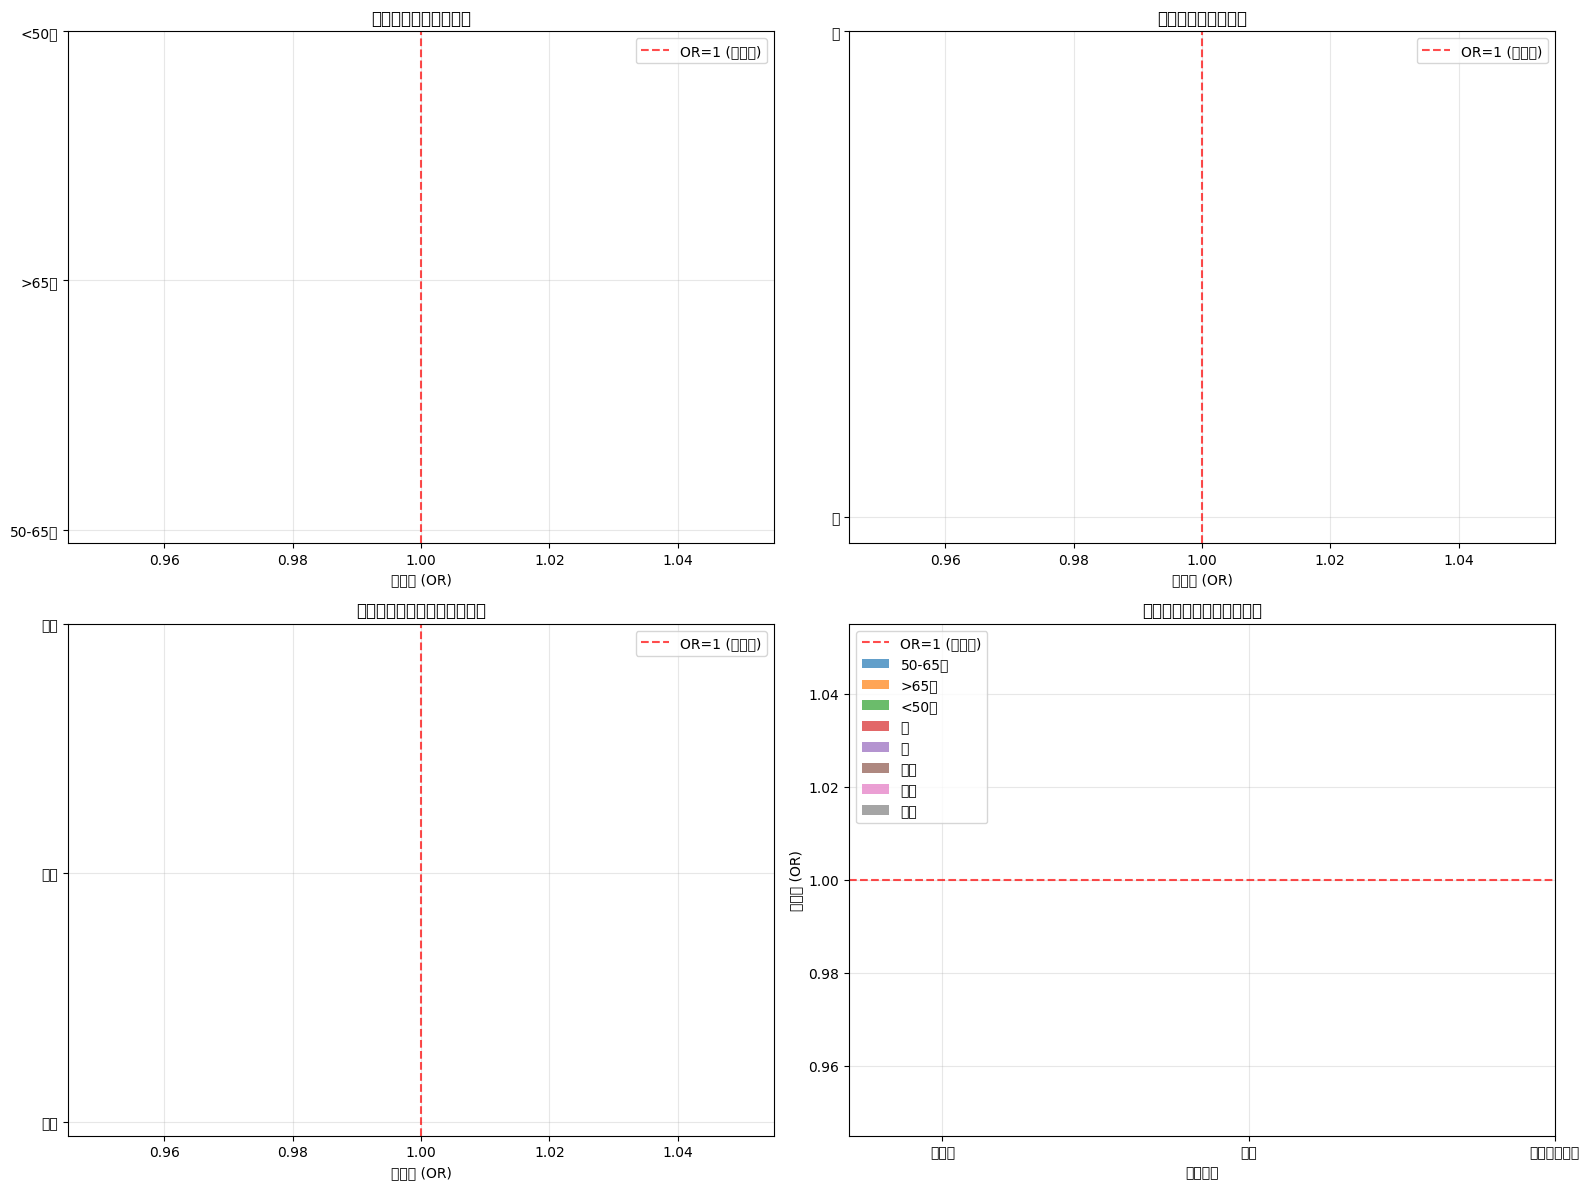

In [34]:
# 6. 分层分析结果可视化
print("\n6. 分层分析结果可视化")
print("-" * 40)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 年龄组优势比森林图
if len(age_results_df) > 0:
    y_pos = range(len(age_results_df))
    axes[0,0].errorbar(age_results_df['odds_ratio'], y_pos, 
                       xerr=[age_results_df['odds_ratio'] - age_results_df['ci_lower'],
                             age_results_df['ci_upper'] - age_results_df['odds_ratio']],
                       fmt='o', capsize=5, capthick=2)
    axes[0,0].axvline(1, color='red', linestyle='--', alpha=0.7, label='OR=1 (无关联)')
    axes[0,0].set_yticks(y_pos)
    axes[0,0].set_yticklabels(age_results_df['age_group'])
    axes[0,0].set_xlabel('优势比 (OR)')
    axes[0,0].set_title('按年龄组分层的优势比')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

# 2. 性别优势比森林图
if len(gender_results_df) > 0:
    y_pos = range(len(gender_results_df))
    axes[0,1].errorbar(gender_results_df['odds_ratio'], y_pos, 
                       xerr=[gender_results_df['odds_ratio'] - gender_results_df['ci_lower'],
                             gender_results_df['ci_upper'] - gender_results_df['odds_ratio']],
                       fmt='s', capsize=5, capthick=2, color='green')
    axes[0,1].axvline(1, color='red', linestyle='--', alpha=0.7, label='OR=1 (无关联)')
    axes[0,1].set_yticks(y_pos)
    axes[0,1].set_yticklabels(gender_results_df['gender'])
    axes[0,1].set_xlabel('优势比 (OR)')
    axes[0,1].set_title('按性别分层的优势比')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

# 3. 疾病严重程度优势比森林图
if len(severity_results_df) > 0:
    y_pos = range(len(severity_results_df))
    axes[1,0].errorbar(severity_results_df['odds_ratio'], y_pos, 
                       xerr=[severity_results_df['odds_ratio'] - severity_results_df['ci_lower'],
                             severity_results_df['ci_upper'] - severity_results_df['odds_ratio']],
                       fmt='^', capsize=5, capthick=2, color='orange')
    axes[1,0].axvline(1, color='red', linestyle='--', alpha=0.7, label='OR=1 (无关联)')
    axes[1,0].set_yticks(y_pos)
    axes[1,0].set_yticklabels(severity_results_df['disease_severity'])
    axes[1,0].set_xlabel('优势比 (OR)')
    axes[1,0].set_title('按疾病严重程度分层的优势比')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

# 4. 分层变量与优势比的关系
all_stratified = []
if len(age_results_df) > 0:
    age_results_df['stratification'] = '年龄组'
    age_results_df['strata'] = age_results_df['age_group']
    all_stratified.append(age_results_df[['strata', 'odds_ratio', 'stratification']])

if len(gender_results_df) > 0:
    gender_results_df['stratification'] = '性别'
    gender_results_df['strata'] = gender_results_df['gender']
    all_stratified.append(gender_results_df[['strata', 'odds_ratio', 'stratification']])

if len(severity_results_df) > 0:
    severity_results_df['stratification'] = '疾病严重程度'
    severity_results_df['strata'] = severity_results_df['disease_severity']
    all_stratified.append(severity_results_df[['strata', 'odds_ratio', 'stratification']])

if all_stratified:
    combined_stratified = pd.concat(all_stratified, ignore_index=True)
    
    # 创建分组条形图
    stratifications = combined_stratified['stratification'].unique()
    x_pos = np.arange(len(stratifications))
    width = 0.25
    
    for i, strata in enumerate(combined_stratified['strata'].unique()):
        strata_data = combined_stratified[combined_stratified['strata'] == strata]
        axes[1,1].bar(x_pos + i*width, strata_data['odds_ratio'], width, 
                     label=strata, alpha=0.7)
    
    axes[1,1].set_xlabel('分层变量')
    axes[1,1].set_ylabel('优势比 (OR)')
    axes[1,1].set_title('不同分层变量的优势比比较')
    axes[1,1].set_xticks(x_pos + width)
    axes[1,1].set_xticklabels(stratifications)
    axes[1,1].axhline(1, color='red', linestyle='--', alpha=0.7, label='OR=1 (无关联)')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [35]:
# 7. 分层分析总结报告
print("\n7. 分层分析总结报告")
print("="*60)

print("分层分析的主要发现:")
print("-" * 30)

# 年龄组分析总结
if len(age_results_df) > 0:
    print(f"\n年龄组分析:")
    print(f"  优势比范围: [{age_results_df['odds_ratio'].min():.3f}, {age_results_df['odds_ratio'].max():.3f}]")
    print(f"  平均优势比: {age_results_df['odds_ratio'].mean():.3f}")
    print(f"  优势比变异系数: {age_results_df['odds_ratio'].std()/age_results_df['odds_ratio'].mean():.3f}")
    
    # 找出优势比最高和最低的年龄组
    max_age_idx = age_results_df['odds_ratio'].idxmax()
    min_age_idx = age_results_df['odds_ratio'].idxmin()
    print(f"  最高优势比: {age_results_df.loc[max_age_idx, 'age_group']} (OR={age_results_df.loc[max_age_idx, 'odds_ratio']:.3f})")
    print(f"  最低优势比: {age_results_df.loc[min_age_idx, 'age_group']} (OR={age_results_df.loc[min_age_idx, 'odds_ratio']:.3f})")

# 性别分析总结
if len(gender_results_df) > 0:
    print(f"\n性别分析:")
    print(f"  优势比范围: [{gender_results_df['odds_ratio'].min():.3f}, {gender_results_df['odds_ratio'].max():.3f}]")
    print(f"  平均优势比: {gender_results_df['odds_ratio'].mean():.3f}")
    
    # 比较男女差异
    if len(gender_results_df) == 2:
        male_or = gender_results_df[gender_results_df['gender'] == '男']['odds_ratio'].iloc[0]
        female_or = gender_results_df[gender_results_df['gender'] == '女']['odds_ratio'].iloc[0]
        print(f"  男性优势比: {male_or:.3f}")
        print(f"  女性优势比: {female_or:.3f}")
        print(f"  男女优势比比值: {male_or/female_or:.3f}")

# 疾病严重程度分析总结
if len(severity_results_df) > 0:
    print(f"\n疾病严重程度分析:")
    print(f"  优势比范围: [{severity_results_df['odds_ratio'].min():.3f}, {severity_results_df['odds_ratio'].max():.3f}]")
    print(f"  平均优势比: {severity_results_df['odds_ratio'].mean():.3f}")
    
    # 按严重程度排序
    severity_sorted = severity_results_df.sort_values('odds_ratio')
    print(f"  按优势比排序:")
    for idx, row in severity_sorted.iterrows():
        print(f"    {row['disease_severity']}: OR={row['odds_ratio']:.3f}")

print(f"\n交互作用分析结果:")
print("-" * 20)
if age_interaction_p is not None:
    print(f"  年龄组交互作用: p={age_interaction_p:.4f} {'(显著)' if age_interaction_p < 0.05 else '(不显著)'}")
if gender_interaction_p is not None:
    print(f"  性别交互作用: p={gender_interaction_p:.4f} {'(显著)' if gender_interaction_p < 0.05 else '(不显著)'}")
if severity_interaction_p is not None:
    print(f"  疾病严重程度交互作用: p={severity_interaction_p:.4f} {'(显著)' if severity_interaction_p < 0.05 else '(不显著)'}")

print(f"\n临床建议:")
print("-" * 20)
print("1. 分层分析有助于识别高风险亚群")
print("2. 如果存在显著交互作用，应考虑分层报告结果")
print("3. 不同亚群可能需要不同的临床管理策略")
print("4. 优势比在不同亚群中的一致性很重要")

print(f"\n统计注意事项:")
print("-" * 20)
print("1. 分层后样本量可能较小，影响统计功效")
print("2. 多重比较需要校正p值")
print("3. 交互作用检验需要足够的样本量")
print("4. 分层变量的选择应基于临床意义")



7. 分层分析总结报告
分层分析的主要发现:
------------------------------

年龄组分析:
  优势比范围: [inf, inf]
  平均优势比: inf
  优势比变异系数: nan
  最高优势比: 50-65岁 (OR=inf)
  最低优势比: 50-65岁 (OR=inf)

性别分析:
  优势比范围: [inf, inf]
  平均优势比: inf
  男性优势比: inf
  女性优势比: inf
  男女优势比比值: nan

疾病严重程度分析:
  优势比范围: [inf, inf]
  平均优势比: inf
  按优势比排序:
    中度: OR=inf
    轻度: OR=inf
    重度: OR=inf

交互作用分析结果:
--------------------
  性别交互作用: p=1.0000 (不显著)
  疾病严重程度交互作用: p=0.9999 (不显著)

临床建议:
--------------------
1. 分层分析有助于识别高风险亚群
2. 如果存在显著交互作用，应考虑分层报告结果
3. 不同亚群可能需要不同的临床管理策略
4. 优势比在不同亚群中的一致性很重要

统计注意事项:
--------------------
1. 分层后样本量可能较小，影响统计功效
2. 多重比较需要校正p值
3. 交互作用检验需要足够的样本量
4. 分层变量的选择应基于临床意义


/opt/anaconda3/envs/scanpy/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/var/folders/dq/m9jbf2_x2_v6cnd1c0nt1rc40000gn/T/ipykernel_7925/3149220661.py:33: RuntimeWarning: invalid value encountered in scalar divide
  print(f"  男女优势比比值: {male_or/female_or:.3f}")


In [36]:
# 6. 使用GEE进行高级统计分析
print("\n6. 使用GEE进行高级统计分析")
print("-" * 30)

try:
    from statsmodels.genmod.families import Binomial
    from statsmodels.genmod.dependence_structures import Exchangeable
    import statsmodels.api as sm
    
    # 使用GEE分析
    model = sm.GEE.from_formula(
        'drug_b_ae ~ drug_a_ae', 
        groups='patient_id',  # 按病人分组
        data=df,
        family=Binomial(),
        cov_struct=Exchangeable()  # 可交换相关结构
    )
    
    result = model.fit()
    
    print("GEE模型结果:")
    print(result.summary())
    
    # 提取关键结果
    coef = result.params['drug_a_ae']
    p_value = result.pvalues['drug_a_ae']
    ci_lower = result.conf_int().loc['drug_a_ae', 0]
    ci_upper = result.conf_int().loc['drug_a_ae', 1]
    
    # 将系数转换为优势比
    gee_or = np.exp(coef)
    gee_or_ci_lower = np.exp(ci_lower)
    gee_or_ci_upper = np.exp(ci_upper)
    
    print(f"\nGEE分析结果:")
    print(f"系数: {coef:.4f}")
    print(f"优势比 (OR): {gee_or:.4f}")
    print(f"95%置信区间: [{gee_or_ci_lower:.4f}, {gee_or_ci_upper:.4f}]")
    print(f"P值: {p_value:.4f}")
    
    # 工作相关结构
    print(f"\n工作相关结构参数: {result.cov_struct.dep_params}")
    
except Exception as e:
    print(f"GEE分析出错: {e}")
    print("可能是数据量太小或模型收敛问题")
    gee_or = None



6. 使用GEE进行高级统计分析
------------------------------
GEE分析出错: No module named 'statsmodels.genmod.dependence_structures'
可能是数据量太小或模型收敛问题
